<a href="https://colab.research.google.com/github/bayuence/CV-ADK-Akbar-Dharma-Karya/blob/main/3012310007_Pengolahan_Citra_Bayu_Nurcahyo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: Bayu Nurcahyo

Nim : 3012310007

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Muat Gambar Percobaan

In [10]:
# Path ke gambar Anda di Colab (yang Anda berikan sebagai konteks)
image_path = '/content/drive/My Drive/IntroDPI_A_0007/foto.jpeg'

# Baca gambar menggunakan OpenCV
img_bgr = cv2.imread(image_path)

# Cek apakah gambar berhasil dimuat
if img_bgr is None:
    print(f"Error: Tidak dapat memuat gambar dari {image_path}. Harap periksa path dan pastikan file ada.")
else:
    print(f"Gambar '{image_path}' berhasil dimuat.")

# Resize agar tidak terlalu besar (sesuai contoh teman Anda)
# Jika gambar Anda berbeda aspek rasio, mungkin perlu penyesuaian agar tidak terdistorsi.
img_bgr = cv2.resize(img_bgr, (300, 300))

Gambar '/content/drive/My Drive/IntroDPI_A_0007/foto.jpeg' berhasil dimuat.


### Pemrosesan Awal dan Tampilan Gambar



Tipe data: <class 'numpy.ndarray'>
Shape : (300, 300, 3)
Dtype : uint8

Artinya:
 Tinggi = 300 piksel
 Lebar = 300 piksel
 Channel = 3 (BGR)
Total piksel:  90000


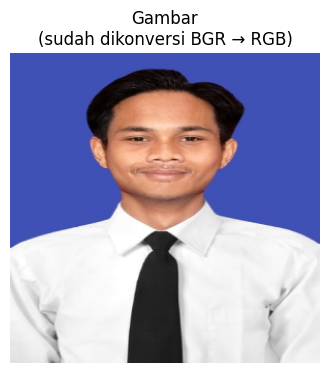

In [11]:
# Cek tipe data: ternyata sudah array NumPy!
print("Tipe data:", type(img_bgr)) # numpy.ndarray
print("Shape :" , img_bgr.shape) # (Tinggi, Lebar, Channel)
print("Dtype :" ,img_bgr.dtype) # uint8

print()
print("Artinya:")
print(f" Tinggi = {img_bgr.shape[0]} piksel")
print(f" Lebar = {img_bgr.shape[1]} piksel")
print(f" Channel = {img_bgr.shape[2]} (BGR)")

# Konversi BGR → RGB untuk ditampilkan di Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Total piksel: ", img_bgr.shape[0] * img_bgr.shape[1])

# Tampilkan gambar
plt.figure(figsize=(4, 6))
plt.imshow(img_rgb)
plt.title('Gambar\n(sudah dikonversi BGR → RGB)')
plt.axis('off')
plt.show()

### Konversi ke Grayscale dan Analisis Area 8x8 Piksel



=== MATRIKS f(x,y) - Area 8x8 Piksel ===
Setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)

[[251 250 249 249 249 248 248 248]
 [252 252 251 251 250 249 247 247]
 [253 253 250 250 250 249 248 248]
 [252 253 251 251 250 249 249 249]
 [251 252 252 251 251 250 250 249]
 [250 251 252 252 251 251 250 250]
 [249 249 250 250 250 250 250 250]
 [248 249 249 249 249 249 249 249]]

Contoh baca: f (180, 200) = 251
Contoh baca: f (181, 201) = 252

=== Ukuran Gambar Grayscale ===
Total piksel grayscale: 90000
Total ukuran grayscale (KB): 90
Total ukuran grayscale (MB): 0.09


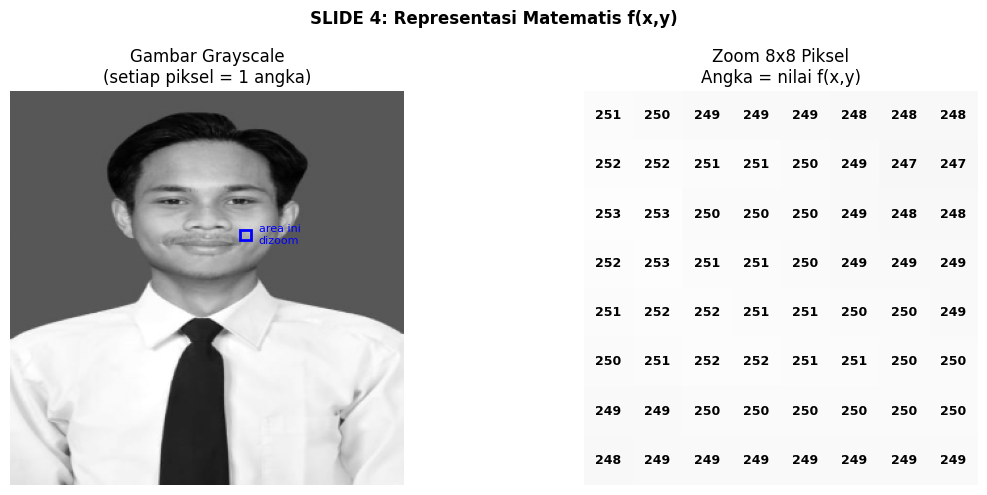

In [12]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Ambil area kecil 8x8 piksel dari tengah gambar
# Koordinat 200:208, 180:188 adalah contoh, mungkin perlu disesuaikan dengan isi gambar Anda.
area_kecil = img_gray[200:208, 180:188]

print("=== MATRIKS f(x,y) - Area 8x8 Piksel ===")
print("Setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)")
print()
print(area_kecil)
print()
# Contoh baca juga disesuaikan dengan koordinat area kecil
print("Contoh baca:" , f"f (180, 200) = {img_gray[200, 180] if 200<img_gray.shape[0] and 180<img_gray.shape[1] else 'Koordinat di luar gambar'}")
print("Contoh baca:", f"f (181, 201) = {img_gray[201, 181] if 201<img_gray.shape[0] and 181<img_gray.shape[1] else 'Koordinat di luar gambar'}")

# Hitung dan cetak ukuran gambar grayscale
total_pixel_gray = img_gray.shape[0] * img_gray.shape[1]
konversi_kb_gray = total_pixel_gray / 1000
konversi_mb_gray = total_pixel_gray / 1000000

print("\n=== Ukuran Gambar Grayscale ===")
print("Total piksel grayscale:", total_pixel_gray)
print("Total ukuran grayscale (KB):", round(konversi_kb_gray))
print("Total ukuran grayscale (MB):", round(konversi_mb_gray, 2))

# Tampilkan area kecil dengan nilai angkanya
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Kiri: gambar grayscale penuh
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Gambar Grayscale\n(setiap piksel = 1 angka)')
axes[0].axis ('off')
# Tandai area yang kita zoom (sesuaikan koordinat jika perlu)
import matplotlib.patches as patches
rect = patches.Rectangle((175, 105), 8, 8, linewidth=2, edgecolor='blue', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(189, 116, 'area ini\ndizoom', color='blue', fontsize=8)

# Kanan: tampilkan nilai angka pada setiap piksel
axes[1].imshow(area_kecil, cmap='gray', vmin=0, vmax=255)
for i in range(8):
  for j in range (8):
    nilai = area_kecil[i,j]
    warna_teks = 'white' if nilai < 128 else 'black'
    axes[1].text(j, i, str(nilai), ha='center', va='center', fontsize=9,color=warna_teks, fontweight='bold')

axes[1].set_title('Zoom 8x8 Piksel\nAngka = nilai f(x,y)')
axes[1].axis('off')

plt.suptitle('SLIDE 4: Representasi Matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()

### Analisis Area 8x8 Piksel RGB


=== MATRIKS f(x,y) - Area 8x8 Piksel ===
Setiap piksel berisi 3 nilai (R, G, B) untuk representasi warna

[[[251 251 251]
  [250 250 250]
  [249 249 249]
  [249 249 249]
  [249 249 249]
  [248 248 248]
  [248 248 248]
  [248 248 248]]

 [[252 252 252]
  [252 252 252]
  [251 251 251]
  [251 251 251]
  [250 250 250]
  [249 249 249]
  [247 247 247]
  [247 247 247]]

 [[253 253 253]
  [253 253 253]
  [250 250 250]
  [250 250 250]
  [250 250 250]
  [249 249 249]
  [248 248 248]
  [248 248 248]]

 [[252 252 252]
  [253 253 253]
  [251 251 251]
  [251 251 251]
  [250 250 250]
  [249 249 249]
  [249 249 249]
  [249 249 249]]

 [[251 251 251]
  [252 252 252]
  [252 252 252]
  [251 251 251]
  [251 251 251]
  [250 250 250]
  [250 250 250]
  [249 249 249]]

 [[250 250 250]
  [251 251 251]
  [252 252 252]
  [252 252 252]
  [251 251 251]
  [251 251 251]
  [250 250 250]
  [250 250 250]]

 [[249 249 249]
  [249 249 249]
  [250 250 250]
  [250 250 250]
  [250 250 250]
  [250 250 250]
  [250 250 250]
  

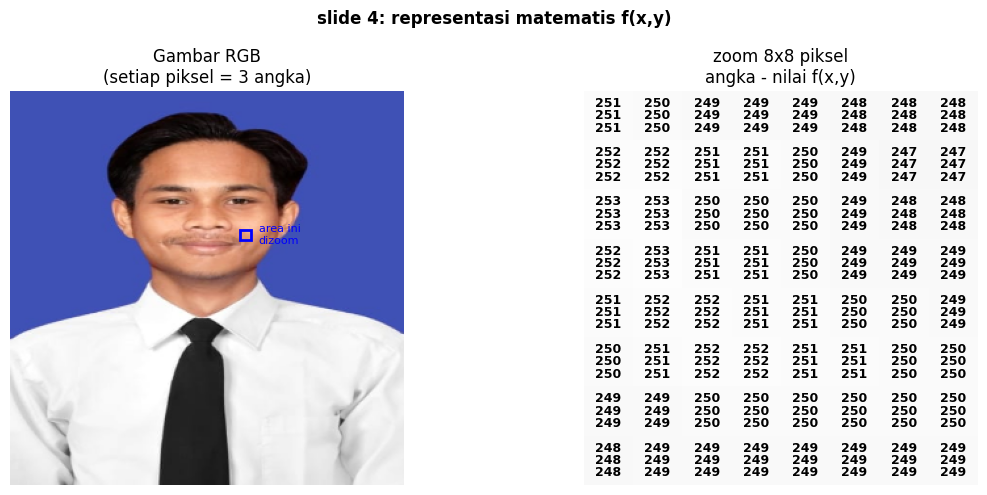

In [13]:
#Ambil area kecil
# Koordinat 200:208, 180:188 adalah contoh, mungkin perlu disesuaikan dengan isi gambar Anda.
area_kecil_rgb = img_rgb[200:208, 180:188]

print("=== MATRIKS f(x,y) - Area 8x8 Piksel ===")
print("Setiap piksel berisi 3 nilai (R, G, B) untuk representasi warna")
print()
print(area_kecil_rgb)
print()
# Contoh baca juga disesuaikan dengan koordinat area kecil
print("CONTOH baca:" , f"f (210, 190) = ({img_rgb[210, 190] if 210<img_rgb.shape[0] and 190<img_rgb.shape[1] else 'Koordinat di luar gambar'}) ")
print("CONTOH baca:" , f"f(211, 191) = ({img_rgb[211,191] if 211<img_rgb.shape[0] and 191<img_rgb.shape[1] else 'Koordinat di luar gambar'}) ")

total_pixel = img_rgb.shape[0] * img_rgb.shape[1]
konversi_kb = (total_pixel*3)/1000 # *3 karena ada 3 channel (R,G,B)
konversi_mb = (total_pixel*3)/1000000

print("\n=== Ukuran Gambar RGB ===")
print("Total piksel RGB:", total_pixel)
print("Total ukuran RGB (KB):" , round(konversi_kb))
print("Total ukuran RGB (MB):" , round(konversi_mb, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Kiri: gambar rgb penuh
axes[0].imshow(img_rgb, vmin=0, vmax=255)
axes[0].set_title('Gambar RGB\n(setiap piksel = 3 angka)')
axes[0].axis ('off')
# Tandai area yang kita zoom (sesuaikan koordinat jika perlu)
import matplotlib.patches as patches
rect = patches.Rectangle((175, 105), 8, 8, linewidth=2, edgecolor='blue', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(189, 116, 'area ini\ndizoom', color='blue', fontsize=8)

def tentukan_warna(skor):
  match skor:
    case r if r < 125:
      return 'white'
    case _:
      return 'black'

axes[1].imshow(area_kecil_rgb)
for i in range(8):
  for j in range(8):
    nilai_rgb = area_kecil_rgb[i,j]
    offsets = [-0.25,0,0.25]
    for mn in range(3):
      nilai_rgb_satuan = nilai_rgb[mn]
      hasil_cek = tentukan_warna(nilai_rgb_satuan)
      axes[1].text (j, i + offsets[mn], str(nilai_rgb_satuan), ha='center', va='center' ,fontsize=9, color=hasil_cek, fontweight='bold')

axes[1].set_title('zoom 8x8 piksel\nangka - nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()